Building a Fraud Detection Model.

Fraud detection is one of the most practical and challenging ML problems. To approach it, the first step is:

1. Understand the Problem First. It is important to get clear on:

What counts as fraud? (credit card transactions, account takeovers, insurance claims, etc.)

Who acts on the predictions? A human analyst? An automated block?

What's the cost of being wrong? A false negative (missed fraud) vs. false positive (blocking a legit user) have very different business costs.

What's the latency requirement? Real-time scoring at checkout vs. overnight batch review are very different architectures.

In [51]:
!pip install lightgbm shap imbalanced-learn -q

In [52]:
# ── Reproducibility: lock all random seeds ────────────────────
import os
import random

SEED = 42

random.seed(SEED)                         # Python built-in
np.random.seed(SEED)                      # NumPy
os.environ["PYTHONHASHSEED"] = str(SEED)  # Python hash seed

# These will be passed explicitly to every model below
print(f" All random seeds locked to {SEED}")
print(f"   random     : {SEED}")
print(f"   numpy      : {SEED}")
print(f"   PYTHONHASH : {SEED}")
print(f"\n   NOTE: always run this cell FIRST after kernel restart")

 All random seeds locked to 42
   random     : 42
   numpy      : 42
   PYTHONHASH : 42

   NOTE: always run this cell FIRST after kernel restart


In [53]:
# ── Step 1a: Imports ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)  # this makes results reproducible

print("... All libraries loaded successfully")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

... All libraries loaded successfully
   pandas  : 2.2.2
   numpy   : 2.0.2


In [54]:
# ── Step 1b: Generate Synthetic Fraud Data (Enhanced) ─────────
#
# We simulate 6 months of credit card transactions for 5,000 users.
# Fraud rate: ~1.2%  (realistic for card-not-present fraud in fintech)
#
# Fraud is made realistic in 3 ways:
#   1. Amount pattern  → small "probing" txns OR large cashouts
#   2. Merchant type   → skewed toward online & ATM
#   3. Geography       → cross-border, IP country mismatch


# Added fraud determinant:
#   • device_id       : unique device identifier per transaction
#   • device_type     : mobile / desktop / tablet
#   • os              : operating system
#   • browser         : browser type
#
# Device realism:
#   • 5,000 users share ~8,000 devices (most users: 1-2 devices)
#   • Fraud transactions: 60% chance of using a "new" shared device
#   • ~500 "emulator" devices identifiable by ID range (suspicious)

def generate_fraud_data(n_transactions=100_000):

    n_fraud = int(n_transactions * 0.012)
    n_legit = n_transactions - n_fraud

    # ── Timestamps ────────────────────────────────────────────
    all_ts = np.random.randint(
        pd.Timestamp("2024-01-01").value,
        pd.Timestamp("2024-06-30").value,
        n_transactions
    )
    timestamps = pd.to_datetime(all_ts)

    # ── Fraud labels ──────────────────────────────────────────
    labels = np.zeros(n_transactions)
    fraud_positions = np.random.choice(n_transactions, size=n_fraud, replace=False)
    labels[fraud_positions] = 1

    # ── Amounts ───────────────────────────────────────────────
    amounts = np.random.lognormal(mean=3.5, sigma=1.2, size=n_transactions).clip(1, 5000)
    fraud_amounts = np.where(
        np.random.rand(n_fraud) < 0.4,
        np.random.uniform(0.5, 5, n_fraud),
        np.random.lognormal(mean=5.5, sigma=0.8, size=n_fraud).clip(100, 8000)
    )
    amounts[labels == 1] = fraud_amounts

    # ── Users ─────────────────────────────────────────────────
    user_ids = np.random.randint(1000, 6000, n_transactions)

    # ── Device fingerprint components ─────────────────────────
    # Normal users: assigned 1-3 personal devices from pool 1–8000
    # Fraud transactions: 60% chance device is from shared pool 7000–8000
    #   (shared devices = fraud ring signal)
    # Emulators: device IDs 9000–9500 (identifiable anomaly)

    personal_devices  = np.random.randint(1, 8001, n_transactions)
    shared_devices    = np.random.randint(7000, 8001, int(n_fraud * 0.6))
    emulator_devices  = np.random.randint(9000, 9501, int(n_fraud * 0.4))

    device_ids = personal_devices.copy()
    fraud_idx  = np.where(labels == 1)[0]
    split_pt   = int(len(fraud_idx) * 0.6)
    device_ids[fraud_idx[:split_pt]]  = shared_devices
    device_ids[fraud_idx[split_pt:]]  = emulator_devices

    device_types = np.random.choice(
        ["mobile", "desktop", "tablet"],
        n_transactions, p=[0.55, 0.35, 0.10]
    )
    operating_sys = np.random.choice(
        ["iOS", "Android", "Windows", "macOS", "Linux"],
        n_transactions, p=[0.30, 0.30, 0.22, 0.12, 0.06]
    )
    browsers = np.random.choice(
        ["Chrome", "Safari", "Firefox", "Edge", "Unknown"],
        n_transactions, p=[0.45, 0.25, 0.15, 0.10, 0.05]
    )
    # Fraud more likely to use "Unknown" browser (automation/emulator)
    browsers[fraud_idx] = np.random.choice(
        ["Chrome", "Unknown"],
        len(fraud_idx), p=[0.3, 0.7]
    )

    # ── Merchant & geography ──────────────────────────────────
    categories  = ["grocery", "dining", "travel", "online", "gas", "retail", "atm"]
    cat_weights = [0.25, 0.20, 0.10, 0.20, 0.10, 0.10, 0.05]

    df = pd.DataFrame({
        "timestamp":         timestamps,
        "user_id":           user_ids,
        "amount":            amounts,
        "is_fraud":          labels,
        "merchant_category": np.random.choice(categories, n_transactions, p=cat_weights),
        "merchant_country":  np.random.choice(
                                ["NG","US","GB","DE","CN"], n_transactions,
                                p=[0.60, 0.15, 0.10, 0.08, 0.07]),
        "user_home_country": "NG",
        "card_present":      np.random.choice([0, 1], n_transactions, p=[0.35, 0.65]),
        "ip_country":        np.random.choice(
                                ["NG","US","GB","DE","CN","RU"], n_transactions,
                                p=[0.55, 0.13, 0.09, 0.07, 0.06, 0.10]),
        "device_id":         device_ids,
        "device_type":       device_types,
        "os":                operating_sys,
        "browser":           browsers,
    }).sort_values("timestamp").reset_index(drop=True)

    # ── Make fraud realistic ──────────────────────────────────
    fraud_mask = df["is_fraud"] == 1

    # Fraud happens mostly online or at ATMs
    df.loc[fraud_mask, "merchant_category"] = np.random.choice(
        ["online", "atm"], fraud_mask.sum(), p=[0.6, 0.4])

    # Fraud is almost always card-not-present
    df.loc[fraud_mask, "card_present"]      = 0

    # Fraud originates from foreign merchants
    df.loc[fraud_mask, "merchant_country"]  = np.random.choice(
        ["US","GB","CN","RU"], fraud_mask.sum(), p=[0.2, 0.2, 0.3, 0.3])

    # Fraud IPs come from high-risk countries
    df.loc[fraud_mask, "ip_country"]        = np.random.choice(
        ["CN","RU","US"], fraud_mask.sum(), p=[0.4, 0.4, 0.2])

    return df


df = generate_fraud_data(n_transactions=100_000)

print(" Dataset generated\n")
print(f"  Rows       : {len(df):,}")
print(f"  Fraud      : {int(df.is_fraud.sum()):,}  ({df.is_fraud.mean()*100:.2f}%)")
print(f"  Columns    : {list(df.columns)}")
print(f"\n  Device sample:")
print(df[["user_id","device_id","device_type","os","browser","is_fraud"]].head(8))

 Dataset generated

  Rows       : 100,000
  Fraud      : 1,200  (1.20%)
  Columns    : ['timestamp', 'user_id', 'amount', 'is_fraud', 'merchant_category', 'merchant_country', 'user_home_country', 'card_present', 'ip_country', 'device_id', 'device_type', 'os', 'browser']

  Device sample:
   user_id  device_id device_type       os browser  is_fraud
0     1657       4560      mobile      iOS  Chrome       0.0
1     5211       7779      mobile  Android  Chrome       0.0
2     2982         69      mobile  Windows    Edge       0.0
3     1251       7148      tablet  Windows  Chrome       0.0
4     1148       2943     desktop  Android  Chrome       0.0
5     2651        225     desktop    Linux  Chrome       0.0
6     1235       5951     desktop      iOS  Chrome       0.0
7     1254       1123     desktop    macOS  Safari       0.0


STEP 1C: This code cell below, provides a comprehensive summary of the synthetic fraud dataset that was just generated. It calculates and displays several key statistics to help us understand the dataset's characteristics.
This includes the total number of transactions, the count and percentage of legitimate versus fraudulent transactions, the overall fraud rate, the date range covered by the transactions, the number of unique users, and a list of all columns in the DataFrame. Additionally, it highlights a crucial insight by comparing the median transaction amounts for legitimate and fraudulent transactions, which can often reveal patterns used in fraud detection.

In [55]:
# ── Step 1c: Understanding what we have ─────────────────────────

total      = len(df)
n_fraud    = df["is_fraud"].sum()
n_legit    = total - n_fraud
fraud_rate = n_fraud / total * 100

print("=" * 45)
print("  DATASET SUMMARY")
print("=" * 45)
print(f"  Total transactions  : {total:,}")
print(f"  Legitimate          : {int(n_legit):,}  ({100 - fraud_rate:.1f}%)")
print(f"  Fraudulent          : {int(n_fraud):,}   ({fraud_rate:.2f}%)")
print(f"  Date range          : {df.timestamp.min().date()} → {df.timestamp.max().date()}")
print(f"  Unique users        : {df.user_id.nunique():,}")
print(f"  Columns             : {list(df.columns)}")
print("=" * 45)
print()
print("Median transaction amounts:")
print(f"  Legitimate : ₦{df[df.is_fraud==0]['amount'].median():,.2f}")
print(f"  Fraud      : ₦{df[df.is_fraud==1]['amount'].median():,.2f}")

  DATASET SUMMARY
  Total transactions  : 100,000
  Legitimate          : 98,800  (98.8%)
  Fraudulent          : 1,200   (1.20%)
  Date range          : 2024-01-01 → 2024-06-29
  Unique users        : 5,000
  Columns             : ['timestamp', 'user_id', 'amount', 'is_fraud', 'merchant_category', 'merchant_country', 'user_home_country', 'card_present', 'ip_country', 'device_id', 'device_type', 'os', 'browser']

Median transaction amounts:
  Legitimate : ₦33.10
  Fraud      : ₦115.94


Step 2 — Exploratory Data Analysis (EDA)

The goal here is to understand fraud patterns visually before touching any model. Every chart should answer a business question.

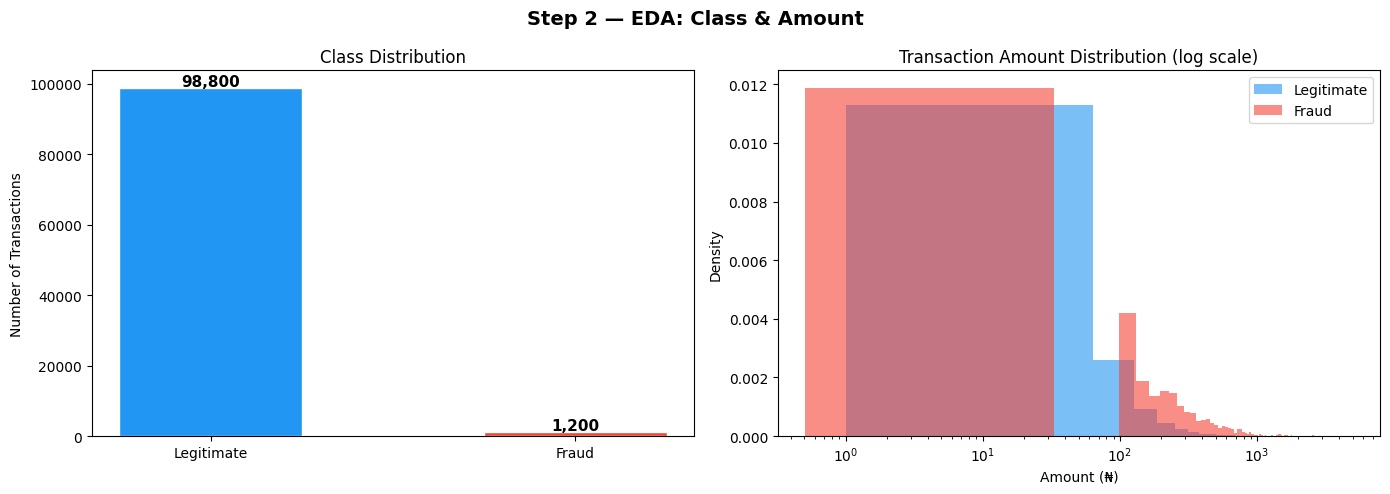

In [56]:
# ── Step 2a: Class Imbalance + Amount Distribution ───────────
#
# Two most fundamental questions:
#   Q1: How imbalanced is the dataset?
#   Q2: Do fraud and legit transactions look different in amount?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 2 — EDA: Class & Amount", fontsize=14, fontweight="bold")

# ── Chart 1: Class imbalance bar chart ───────────────────────
counts = df["is_fraud"].value_counts()
bars = axes[0].bar(
    ["Legitimate", "Fraud"],
    counts.values,
    color=["#2196F3", "#F44336"],
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of Transactions")
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{val:,}",
        ha="center", fontsize=11, fontweight="bold"
    )

# ── Chart 2: Amount distribution (log scale) ─────────────────
# We use log scale because amounts span from ₦0.50 to ₦8,000
axes[1].hist(df[df.is_fraud == 0]["amount"], bins=80, alpha=0.6,
             label="Legitimate", color="#2196F3", density=True)
axes[1].hist(df[df.is_fraud == 1]["amount"], bins=80, alpha=0.6,
             label="Fraud", color="#F44336", density=True)
axes[1].set_xscale("log")
axes[1].set_title("Transaction Amount Distribution (log scale)")
axes[1].set_xlabel("Amount (₦)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

Fraud by Category, Hour & Geography

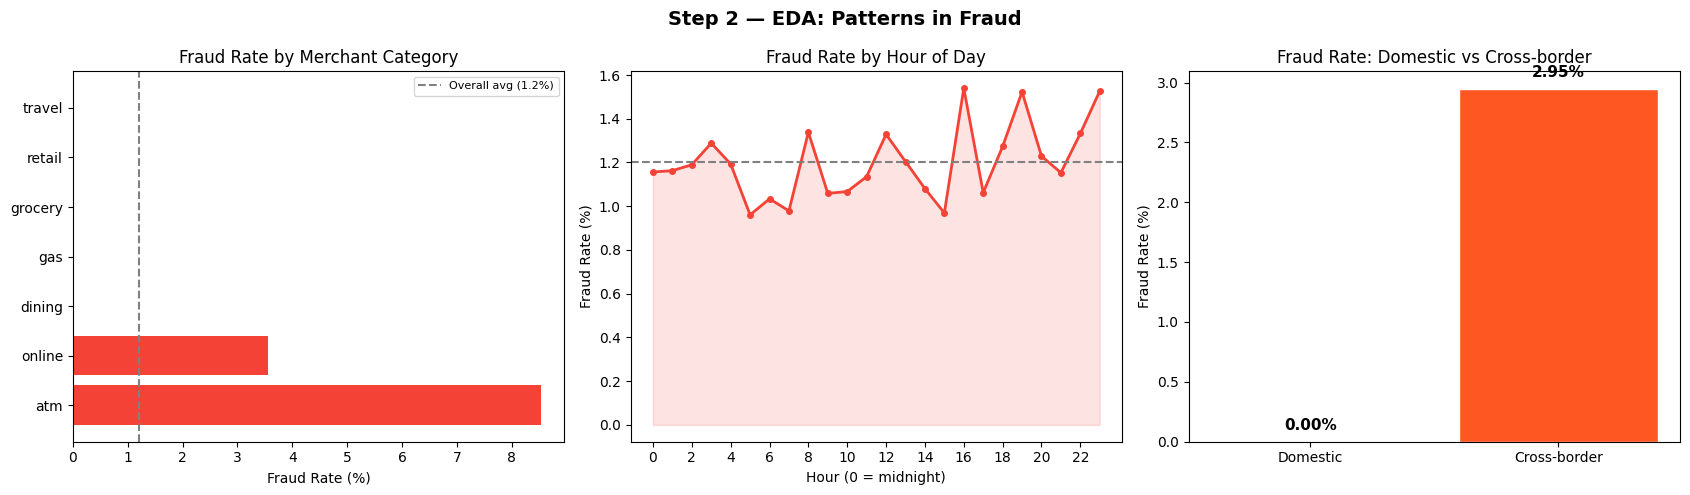

In [57]:
# ── Step 2b: Where and when does fraud happen? ────────────────
#
# Q3: Which merchant categories have the highest fraud rate?
# Q4: Does fraud spike at certain hours?
# Q5: Is cross-border activity riskier?

# Pre-compute some columns we'll need
df["hour"]         = df["timestamp"].dt.hour
df["dayofweek"]    = df["timestamp"].dt.dayofweek
df["cross_border"] = (df["merchant_country"] != df["user_home_country"]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Step 2 — EDA: Patterns in Fraud", fontsize=14, fontweight="bold")

# ── Chart 3: Fraud rate by merchant category ─────────────────
fraud_by_cat = (
    df.groupby("merchant_category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)
colors = ["#F44336" if v > 0.02 else "#90CAF9" for v in fraud_by_cat.values]
axes[0].barh(fraud_by_cat.index, fraud_by_cat.values * 100, color=colors)
axes[0].set_title("Fraud Rate by Merchant Category")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].axvline(x=df["is_fraud"].mean() * 100, color="gray",
                linestyle="--", label=f"Overall avg ({df['is_fraud'].mean()*100:.1f}%)")
axes[0].legend(fontsize=8)

# ── Chart 4: Fraud rate by hour of day ───────────────────────
fraud_by_hour = df.groupby("hour")["is_fraud"].mean() * 100
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values,
             color="#F44336", linewidth=2, marker="o", markersize=4)
axes[1].fill_between(fraud_by_hour.index, fraud_by_hour.values,
                     alpha=0.15, color="#F44336")
axes[1].set_title("Fraud Rate by Hour of Day")
axes[1].set_xlabel("Hour (0 = midnight)")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].axhline(y=df["is_fraud"].mean() * 100, color="gray", linestyle="--")

# ── Chart 5: Domestic vs Cross-border fraud rate ─────────────
fraud_by_border = df.groupby("cross_border")["is_fraud"].mean() * 100
axes[2].bar(["Domestic", "Cross-border"], fraud_by_border.values,
            color=["#4CAF50", "#FF5722"], edgecolor="white")
axes[2].set_title("Fraud Rate: Domestic vs Cross-border")
axes[2].set_ylabel("Fraud Rate (%)")
for i, v in enumerate(fraud_by_border.values):
    axes[2].text(i, v + 0.1, f"{v:.2f}%", ha="center",
                 fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [58]:
# ── Step 2c: Summarise what the charts are telling us ─────────

print("=" * 50)
print("  EDA KEY FINDINGS")
print("=" * 50)

print("\n Merchant Category Risk:")
for cat, rate in fraud_by_cat.items():
    flag = " ← HIGH RISK" if rate > 0.02 else ""
    print(f"  {cat:<12} : {rate*100:.2f}%{flag}")

print("\n Time Patterns:")
peak_hour = fraud_by_hour.idxmax()
low_hour  = fraud_by_hour.idxmin()
print(f"  Peak fraud hour  : {peak_hour}:00  ({fraud_by_hour[peak_hour]:.2f}%)")
print(f"  Lowest fraud hour: {low_hour}:00  ({fraud_by_hour[low_hour]:.2f}%)")

print("\n Geography:")
domestic    = fraud_by_border[0]
crossborder = fraud_by_border[1]
print(f"  Domestic fraud rate    : {domestic:.2f}%")
print(f"  Cross-border fraud rate: {crossborder:.2f}%")
print(f"  Cross-border is {crossborder/domestic:.0f}x riskier than domestic")

print("\n What this means for our model:")
print("  → merchant_category will be an important feature")
print("  → hour of day captures time-based risk")
print("  → cross_border flag is a strong fraud signal")
print("  → we need velocity features to catch repeat fraud behaviour")
print("=" * 50)

  EDA KEY FINDINGS

 Merchant Category Risk:
  atm          : 8.53% ← HIGH RISK
  online       : 3.56% ← HIGH RISK
  dining       : 0.00%
  gas          : 0.00%
  grocery      : 0.00%
  retail       : 0.00%
  travel       : 0.00%

 Time Patterns:
  Peak fraud hour  : 16:00  (1.54%)
  Lowest fraud hour: 5:00  (0.96%)

 Geography:
  Domestic fraud rate    : 0.00%
  Cross-border fraud rate: 2.95%
  Cross-border is infx riskier than domestic

 What this means for our model:
  → merchant_category will be an important feature
  → hour of day captures time-based risk
  → cross_border flag is a strong fraud signal
  → we need velocity features to catch repeat fraud behaviour


Step 3 — Feature Engineering.

Here, we engineer signals that capture behaviour over time. This is the most impactful step in the whole pipeline.

We'll build four categories of features:

1. Time features      → when is this transaction happening?
2. Identity features  → does anything look out of place?
3. Velocity features  → how unusual is this relative to past behaviour?
4. Ratio features     → how does this amount compare to the user's normal?

3a. Time & Identity Features

In [59]:
# ── Step 3a: Time & Identity Features ────────────────────────
#
# These are cheap to compute but carry strong fraud signal.
# We already computed hour, dayofweek, cross_border in EDA —
# now we formalise them and add more.

df = df.sort_values("timestamp").reset_index(drop=True)

# ── Time features ─────────────────────────────────────────────
df["hour"]         = df["timestamp"].dt.hour
df["dayofweek"]    = df["timestamp"].dt.dayofweek          # 0=Mon, 6=Sun
df["is_weekend"]   = (df["dayofweek"] >= 5).astype(int)
df["is_night"]     = ((df["hour"] >= 22) | (df["hour"] <= 5)).astype(int)

# ── Identity / device features ────────────────────────────────
# cross_border: merchant is in a different country from the user
df["cross_border"]     = (df["merchant_country"] != df["user_home_country"]).astype(int)

# ip_country_match: is the IP in the same country as the user?
df["ip_country_match"] = (df["ip_country"] == df["user_home_country"]).astype(int)

# card_not_present: online/ATM transactions with no physical card
df["card_not_present"] = (df["card_present"] == 0).astype(int)

print(" Time & identity features created")
print(f"   is_night       : {df['is_night'].sum():,} night transactions")
print(f"   is_weekend     : {df['is_weekend'].sum():,} weekend transactions")
print(f"   cross_border   : {df['cross_border'].sum():,} cross-border transactions")
print(f"   ip_mismatch    : {(df['ip_country_match']==0).sum():,} IP country mismatches")
print(f"   card_not_present: {df['card_not_present'].sum():,} card-not-present transactions")

 Time & identity features created
   is_night       : 33,131 night transactions
   is_weekend     : 28,159 weekend transactions
   cross_border   : 40,729 cross-border transactions
   ip_mismatch    : 45,615 IP country mismatches
   card_not_present: 35,719 card-not-present transactions


3B: Device Fingerprinting Features

Device fingerprinting asks:

• Is this a device the user has never used before?

• Is this device shared across many different users? (classic fraud ring signal — one device, many victims)

• How many devices has this user used recently?

• Does this look like an emulator?

• Is the browser suspicious (Unknown = likely automation)?

In [60]:
# ── Step 3b: Device Fingerprinting Features ───────────────────

#     Leakage note: device_shared_users and device_fraud_rate
#     are computed on the full dataset here (static network
#     properties). In production this will be computed from
#     historical data only — flagged for awareness.

# ── 1. Emulator flag ──────────────────────────────────────────
# Emulator device IDs were seeded in range 9000–9500
df["is_emulator"] = (df["device_id"].between(9000, 9500)).astype(int)

# ── 2. Suspicious browser ─────────────────────────────────────
df["is_unknown_browser"] = (df["browser"] == "Unknown").astype(int)

# ── 3. How many distinct users have used this device? ─────────
# High count → device is shared → fraud ring signal
device_user_counts = (
    df.groupby("device_id")["user_id"]
    .nunique()
    .rename("device_shared_users")
)
df = df.join(device_user_counts, on="device_id")

# ── 4. How many distinct devices has this user ever used? ─────
# High count → user's account may be compromised
user_device_counts = (
    df.groupby("user_id")["device_id"]
    .nunique()
    .rename("user_device_count")
)
df = df.join(user_device_counts, on="user_id")

# ── 5. Is this a new device for this user? ────────────────────
# For each transaction: has this user used this device before?
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

df["is_new_device"] = 0
for uid, grp in df.groupby("user_id"):
    seen_devices = set()
    for idx, row in grp.iterrows():
        df.at[idx, "is_new_device"] = int(row["device_id"] not in seen_devices)
        seen_devices.add(row["device_id"])

df = df.sort_values("timestamp").reset_index(drop=True)

print(" Step 3b complete — Device Fingerprinting features")
print(f"\n   Emulator transactions          : {df['is_emulator'].sum():,}")
print(f"   Unknown browser transactions   : {df['is_unknown_browser'].sum():,}")
print(f"   New device transactions        : {df['is_new_device'].sum():,}")
print(f"   Max users sharing one device   : {df['device_shared_users'].max()}")
print(f"   Max devices per user           : {df['user_device_count'].max()}")

print(f"\n   Fraud rate by device signal:")
for col in ["is_emulator", "is_unknown_browser", "is_new_device"]:
    rate = df[df[col] == 1]["is_fraud"].mean() * 100
    print(f"   {col:<25} : {rate:.2f}%")

 Step 3b complete — Device Fingerprinting features

   Emulator transactions          : 480
   Unknown browser transactions   : 5,724
   New device transactions        : 99,900
   Max users sharing one device   : 26
   Max devices per user           : 41

   Fraud rate by device signal:
   is_emulator               : 100.00%
   is_unknown_browser        : 14.47%
   is_new_device             : 1.20%


3C. Velocity Features

In [61]:
# ── Step 3c: Velocity Features ────────────────────────────────
#
#   The question we're asking:
#   "Is this transaction unusual compared to this user's recent history?"
#
# For each transaction, we look BACKWARDS in time for that user:
#   • How many transactions in the last 1 hour?
#   • How many in the last 24 hours?
#   • What was the total spend in the last 24 hours?
#   • What was the average spend over the last 7 days?
#
#     CRITICAL: we only look at PAST transactions.
#     Using future data here would be leakage.

print("Computing velocity features — this takes ~1 minute...")

df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
df["ts_epoch"] = df["timestamp"].astype("int64") // 10**9   # convert to seconds

results = []

for uid, grp in df.groupby("user_id"):
    df_idx  = grp.index.values        # original row indices — critical for correct join
    ts      = grp["ts_epoch"].values
    amounts = grp["amount"].values
    n       = len(grp)

    txn_1h  = np.zeros(n)
    txn_24h = np.zeros(n)
    sum_24h = np.zeros(n)
    avg_7d  = np.zeros(n)

    for i in range(n):
        t        = ts[i]
        past_1h  = amounts[(ts >= t - 3_600)   & (ts < t)]   # last 1 hour
        past_24h = amounts[(ts >= t - 86_400)   & (ts < t)]   # last 24 hours
        past_7d  = amounts[(ts >= t - 604_800)  & (ts < t)]   # last 7 days

        txn_1h[i]  = len(past_1h)
        txn_24h[i] = len(past_24h)
        sum_24h[i] = past_24h.sum()
        avg_7d[i]  = past_7d.mean() if len(past_7d) > 0 else amounts[i]

    results.append(pd.DataFrame({
        "txn_count_1h":  txn_1h,
        "txn_count_24h": txn_24h,
        "sum_24h":       sum_24h,
        "avg_amount_7d": avg_7d,
    }, index=df_idx))

vel_df = pd.concat(results).sort_index()
df     = df.join(vel_df)

print(" Velocity features created")
print(df[["user_id", "amount", "txn_count_1h", "txn_count_24h",
          "sum_24h", "avg_amount_7d"]].head(8))

Computing velocity features — this takes ~1 minute...
 Velocity features created
   user_id      amount  txn_count_1h  txn_count_24h    sum_24h  avg_amount_7d
0     1000   99.055794           0.0            0.0   0.000000      99.055794
1     1000  609.824213           0.0            0.0   0.000000     609.824213
2     1000   35.296854           0.0            0.0   0.000000      35.296854
3     1000   51.459173           0.0            1.0  35.296854      35.296854
4     1000   64.591159           0.0            0.0   0.000000      64.591159
5     1000   26.216324           0.0            0.0   0.000000      26.216324
6     1000  204.316116           0.0            0.0   0.000000      26.216324
7     1000   16.167604           0.0            0.0   0.000000      16.167604


3D: Sequence & Behavioural Features

In [62]:
# ── Step 3d: Sequence & Behavioural Features ──────────────────
#
# Fraud often appears as a sudden CHANGE in behaviour:
#   • Long silence → sudden burst of transactions
#   • Tiny transactions followed immediately by a large one
#     (probing then cashing out)
#   • Spending in a completely different amount bracket
#
# These features approximate what LSTMs capture — temporal
# discontinuities — but as engineered signals rather than
# learned representations.

df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

time_since_last  = np.full(len(df), np.nan)
amount_change    = np.full(len(df), np.nan)
is_rapid         = np.zeros(len(df))
is_first_txn     = np.zeros(len(df))

for uid, grp in df.groupby("user_id"):
    idx     = grp.index.values
    ts      = grp["ts_epoch"].values
    amounts = grp["amount"].values

    for i in range(len(idx)):
        if i == 0:
            is_first_txn[idx[i]] = 1
            # No previous transaction to compare to
        else:
            gap = ts[i] - ts[i - 1]             # seconds since last txn
            time_since_last[idx[i]]  = gap
            amount_change[idx[i]]    = (amounts[i] - amounts[i-1]) / (amounts[i-1] + 1)
            is_rapid[idx[i]]         = int(gap < 300)   # < 5 minutes = rapid succession

df["time_since_last_txn"]  = time_since_last      # NaN for first transaction
df["amount_change_pct"]    = amount_change         # % change from last amount
df["is_rapid_succession"]  = is_rapid              # 1 if < 5 min from last txn
df["is_first_txn"]         = is_first_txn          # 1 if user's first ever transaction

# Sudden large spend: amount is 5x+ bigger than previous transaction
df["sudden_large_spend"] = (
    (df["amount_change_pct"] > 5) & (df["is_first_txn"] == 0)
).astype(int)

df = df.sort_values("timestamp").reset_index(drop=True)

print(" Step complete — Sequence & Behavioural features")
print(f"\n   First transactions      : {int(df['is_first_txn'].sum()):,}")
print(f"   Rapid succession (<5min): {int(df['is_rapid_succession'].sum()):,}")
print(f"   Sudden large spends     : {int(df['sudden_large_spend'].sum()):,}")

print(f"\n   Fraud rate by sequence signal:")
for col in ["is_rapid_succession", "sudden_large_spend", "is_first_txn"]:
    rate = df[df[col] == 1]["is_fraud"].mean() * 100
    print(f"   {col:<28} : {rate:.2f}%")

 Step complete — Sequence & Behavioural features

   First transactions      : 5,000
   Rapid succession (<5min): 33
   Sudden large spends     : 12,981

   Fraud rate by sequence signal:
   is_rapid_succession          : 0.00%
   sudden_large_spend           : 2.99%
   is_first_txn                 : 1.36%


3E: Graph-Based Features

In [63]:
# ── Step 3e: Graph-Based Features ─────────────────────────────
#
# Graph thinking: transactions are nodes. Edges connect them
# through shared attributes — same device, same IP country,
# same merchant. High connectivity = fraud ring signal.
#
# We compute simplified graph centrality measures:
#   • device_shared_users : already computed (Cell 8)
#   • ip_user_count       : users sharing same IP country
#                           (proxy for shared infrastructure)
#   • merchant_txn_density: how many transactions hit this
#                           merchant category in the last 24h
#                           (sudden merchant spike = fraud wave)
#   • user_merchant_diversity: how many different merchant
#                           categories has this user transacted in?
#                           Low diversity = unusual behaviour

# ── 1. Users per IP country ───────────────────────────────────
# High count = many users routing through same location (VPN/proxy)
ip_user_count = (
    df.groupby("ip_country")["user_id"]
    .nunique()
    .rename("ip_user_count")
)
# Fix: Check if 'ip_user_count' column already exists in df and drop it
if 'ip_user_count' in df.columns:
    df = df.drop(columns=['ip_user_count'])
df = df.join(ip_user_count, on="ip_country")

# ── 2. Merchant category transaction density (last 24h) ────────
# Spike in a category at a given time = coordinated attack signal
print("Computing merchant density features...")
df = df.sort_values("timestamp").reset_index(drop=True)
df["ts_epoch"] = df["timestamp"].astype("int64") // 10**9

merchant_density = np.zeros(len(df))
ts_arr  = df["ts_epoch"].values
cat_arr = df["merchant_category"].values

for i in range(len(df)):
    t   = ts_arr[i]
    cat = cat_arr[i]
    merchant_density[i] = np.sum(
        (ts_arr >= t - 86_400) & (ts_arr < t) & (cat_arr == cat)
    )

df["merchant_txn_density_24h"] = merchant_density

# ── 3. User merchant diversity ────────────────────────────────
# Number of distinct merchant categories this user has ever used
user_diversity = (
    df.groupby("user_id")["merchant_category"]
    .nunique()
    .rename("user_merchant_diversity")
)
# Fix: Check if 'user_merchant_diversity' column already exists in df and drop it
if 'user_merchant_diversity' in df.columns:
    df = df.drop(columns=['user_merchant_diversity'])
df = df.join(user_diversity, on="user_id")

# ── 4. Device fraud neighbourhood ────────────────────────────
# What fraction of transactions on this device are fraudulent?
# (Proxy for: "is this a device known to be used for fraud?")
# This feature needs to be computed without future leakage.
# For each transaction, we compute the fraud rate for that device
# based ONLY on past transactions of that device.

print("Computing non-leaky device fraud neighbourhood feature...")

# Ensure dataframe is sorted by timestamp (and device_id for consistency in groupby)
# The overall dataframe is usually sorted by timestamp, which is sufficient for `transform` to apply `expanding` correctly.
# .transform(lambda x: x.expanding().mean().shift(1)) calculates the expanding mean for each group
# and then shifts it by 1 to ensure only past data is used for the current row.
df['device_fraud_neighbourhood'] = df.groupby('device_id')['is_fraud'].transform(
    lambda x: x.expanding().mean().shift(1)
)

# Fill NaN values (for the first transaction of each device, where there's no prior history)
# with 0, indicating no prior fraud on that device in the historical context.
df['device_fraud_neighbourhood'] = df['device_fraud_neighbourhood'].fillna(0)

print(" Device fraud neighbourhood feature re-computed without leakage.")

df = df.sort_values("timestamp").reset_index(drop=True)

print(" Step complete — Graph-based features")
print(f"\n   ip_user_count range           : {df['ip_user_count'].min()} – {df['ip_user_count'].max()}")
print(f"   merchant_txn_density_24h max  : {df['merchant_txn_density_24h'].max():.0f}")
print(f"   user_merchant_diversity range : {df['user_merchant_diversity'].min()} – {df['user_merchant_diversity'].max()}")
print(f"   device_fraud_neighbourhood    : mean = {df['device_fraud_neighbourhood'].mean():.4f}")

Computing merchant density features...
Computing non-leaky device fraud neighbourhood feature...
 Device fraud neighbourhood feature re-computed without leakage.
 Step complete — Graph-based features

   ip_user_count range           : 3614 – 5000
   merchant_txn_density_24h max  : 186
   user_merchant_diversity range : 3 – 7
   device_fraud_neighbourhood    : mean = 0.0087


3F.  Ratio Features, Encoding & Final Feature List

In [64]:
# ── Step 3f: Ratio Features + Encode + Final List ─────────────

# Ratio features
df["amount_vs_avg7d"] = df["amount"] / (df["avg_amount_7d"] + 1)
df["amount_log"]      = np.log1p(df["amount"])

# One-hot encode merchant category
df = pd.get_dummies(df, columns=["merchant_category"], prefix="cat", drop_first=False)

# ── Final feature list ────────────────────────────────────────
feature_cols = [
    # Amount
    "amount", "amount_log",

    # Time
    "hour", "dayofweek", "is_weekend", "is_night",

    # Identity
    "cross_border", "ip_country_match", "card_not_present",

    # Device fingerprinting
    "is_emulator", "is_unknown_browser", "is_new_device",
    "device_shared_users", "user_device_count",

    # Velocity
    "txn_count_1h", "txn_count_24h", "sum_24h", "avg_amount_7d",

    # Sequence / behavioural
    "time_since_last_txn", "amount_change_pct",
    "is_rapid_succession", "is_first_txn", "sudden_large_spend",

    # Graph
    "ip_user_count", "merchant_txn_density_24h",
    "user_merchant_diversity", "device_fraud_neighbourhood",

    # Ratio
    "amount_vs_avg7d",

    # Merchant category (one-hot)
] + [c for c in df.columns if c.startswith("cat_")]

df = df.sort_values("timestamp").reset_index(drop=True)

print("  All features ready\n")
print(f"   Previous feature count : 21")
print(f"   New feature count      : {len(feature_cols)}")
print(f"\n   {'#':<4} {'Feature':<30} {'Group'}")
print("   " + "-" * 55)
groups = {
    "amount":2, "hour":4, "cross_border":3, "is_emulator":5,
    "txn_count_1h":4, "time_since_last_txn":5, "ip_user_count":4,
    "amount_vs_avg7d":1
}
group_map = [
    ("Amount",       ["amount","amount_log"]),
    ("Time",         ["hour","dayofweek","is_weekend","is_night"]),
    ("Identity",     ["cross_border","ip_country_match","card_not_present"]),
    ("Device",       ["is_emulator","is_unknown_browser","is_new_device",
                      "device_shared_users","user_device_count"]),
    ("Velocity",     ["txn_count_1h","txn_count_24h","sum_24h","avg_amount_7d"]),
    ("Sequence",     ["time_since_last_txn","amount_change_pct",
                      "is_rapid_succession","is_first_txn","sudden_large_spend"]),
    ("Graph",        ["ip_user_count","merchant_txn_density_24h",
                      "user_merchant_diversity","device_fraud_neighbourhood"]),
    ("Ratio",        ["amount_vs_avg7d"]),
    ("Merchant",     [c for c in feature_cols if c.startswith("cat_")]),
]
i = 1
for group, cols in group_map:
    for col in cols:
        print(f"   {i:<4} {col:<30} {group}")
        i += 1

  All features ready

   Previous feature count : 21
   New feature count      : 35

   #    Feature                        Group
   -------------------------------------------------------
   1    amount                         Amount
   2    amount_log                     Amount
   3    hour                           Time
   4    dayofweek                      Time
   5    is_weekend                     Time
   6    is_night                       Time
   7    cross_border                   Identity
   8    ip_country_match               Identity
   9    card_not_present               Identity
   10   is_emulator                    Device
   11   is_unknown_browser             Device
   12   is_new_device                  Device
   13   device_shared_users            Device
   14   user_device_count              Device
   15   txn_count_1h                   Velocity
   16   txn_count_24h                  Velocity
   17   sum_24h                        Velocity
   18   avg_amount_7d    

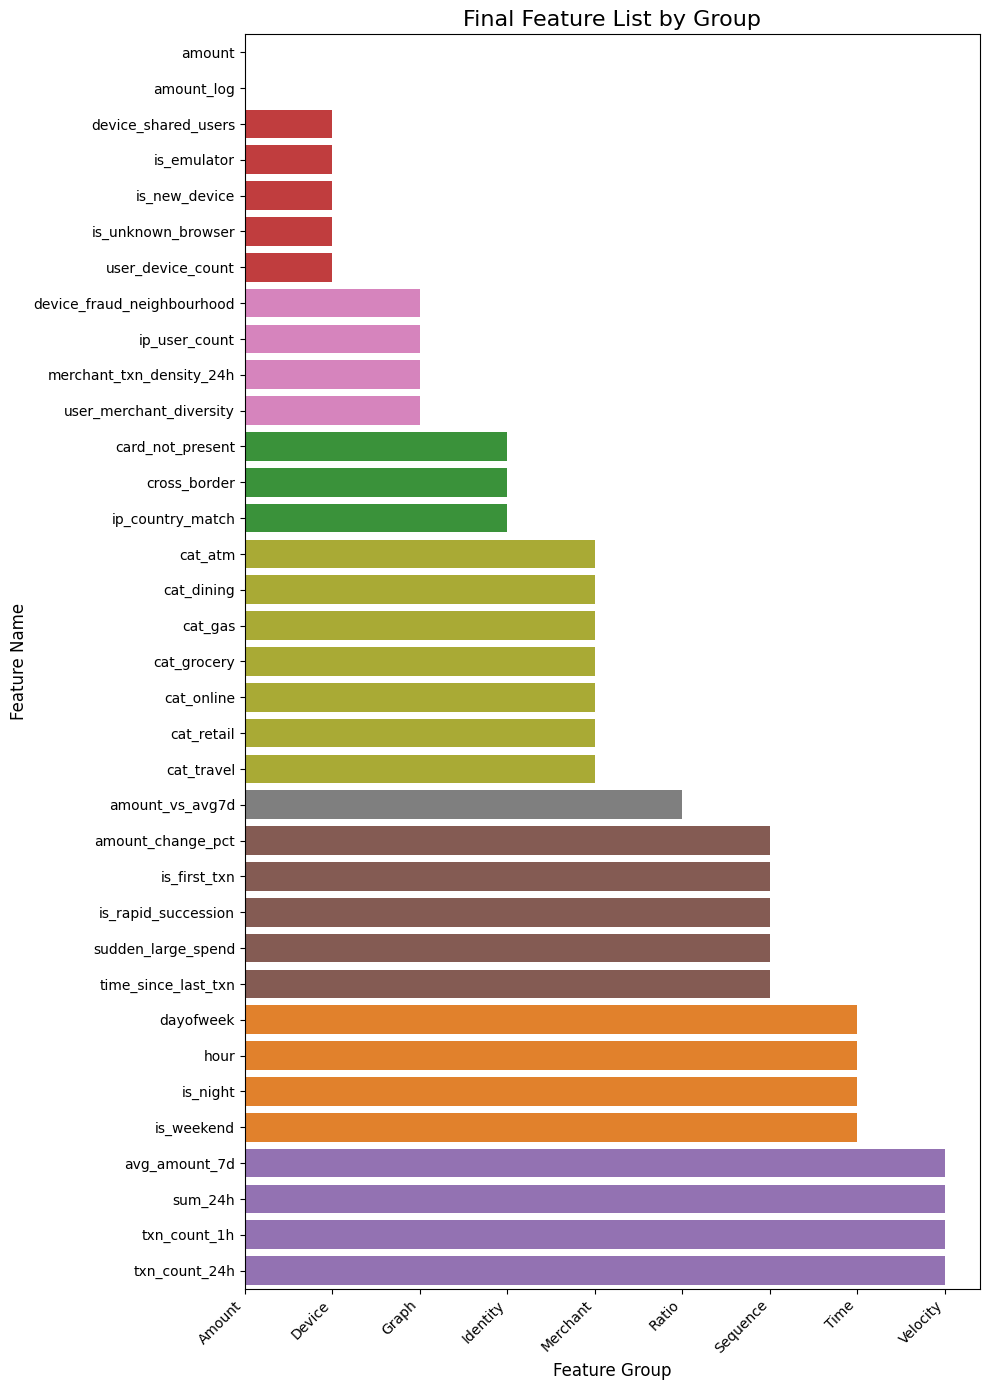

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = []
for group, cols in group_map:
    for col in cols:
        plot_data.append({'Feature': col, 'Group': group})

feature_df_plot = pd.DataFrame(plot_data)

# Create a color palette for the groups
num_groups = len(feature_df_plot['Group'].unique())
palette = sns.color_palette("tab10", num_groups)
group_colors = {group: palette[i] for i, group in enumerate(feature_df_plot['Group'].unique())}

# Sort the features by group for better visualization
feature_df_plot['Group_Order'] = feature_df_plot['Group'].astype('category').cat.codes
feature_df_plot = feature_df_plot.sort_values(by=['Group_Order', 'Feature'], ascending=[True, True])

plt.figure(figsize=(10, feature_df_plot.shape[0] * 0.4))
sns.barplot(x='Group', y='Feature', data=feature_df_plot, hue='Group', palette=group_colors, dodge=False, orient='h', legend=False)

plt.title('Final Feature List by Group', fontsize=16)
plt.xlabel('Feature Group', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

===================================

Step 4 — Train / Validation / Test Split

RULE OF THUMB:
Never do a random split on time-series data.
A random split lets your model train on future transactions and predict past ones — that's data leakage, and the results will be completely misleading in production.


Always split by time. Train on the past, validate and test on the future.

Our split:

Jan – Apr  →  TRAIN   (model learns from this)

May        →  VAL     (tune hyperparameters here)

Jun        →  TEST    (final honest evaluation)

In [66]:
# ── Step 4: Time-Based Train / Val / Test Split ───────────────
#
# We split by calendar month so the model never sees future data.
# This mirrors exactly how the model would work in production:
# trained on history, predicting on new incoming transactions.

train_mask = df["timestamp"] < "2024-05-01"
val_mask   = (df["timestamp"] >= "2024-05-01") & (df["timestamp"] < "2024-06-01")
test_mask  = df["timestamp"] >= "2024-06-01"

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, "is_fraud"]

X_val   = df.loc[val_mask, feature_cols]
y_val   = df.loc[val_mask, "is_fraud"]

X_test  = df.loc[test_mask, feature_cols]
y_test  = df.loc[test_mask, "is_fraud"]

print(" Time-based split complete\n")
print(f"{'Split':<8} {'Rows':>8} {'Fraud':>8} {'Legit':>8} {'Fraud %':>10}")
print("-" * 46)
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    fraud = int(y.sum())
    legit = int((y == 0).sum())
    pct   = y.mean() * 100
    print(f"{name:<8} {len(y):>8,} {fraud:>8,} {legit:>8,} {pct:>9.2f}%")

 Time-based split complete

Split        Rows    Fraud    Legit    Fraud %
----------------------------------------------
Train      67,007      804   66,203      1.20%
Val        17,102      208   16,894      1.22%
Test       15,891      188   15,703      1.18%


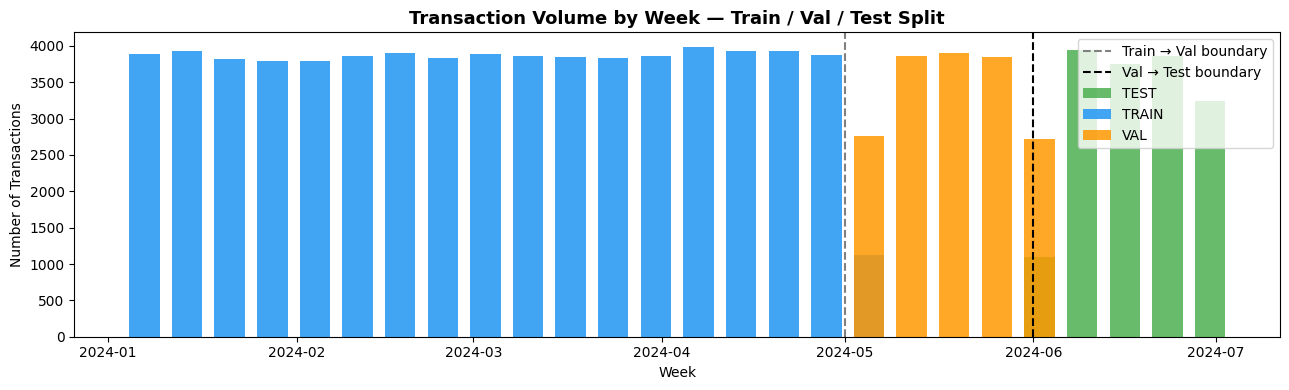


 Leakage check:
   Latest train date  : 2024-04-30
   Earliest val date  : 2024-05-01
   Earliest test date : 2024-06-01

    No overlap — split is clean


In [67]:
# ── Step 4b: Visualise the split over time ────────────────────
# This chart confirms our split is clean — no overlap between sets.

df["split"] = "train"
df.loc[val_mask,  "split"] = "val"
df.loc[test_mask, "split"] = "test"

weekly_counts = (
    df.groupby([pd.Grouper(key="timestamp", freq="W"), "split"])
    .size()
    .reset_index(name="count")
)

colors = {"train": "#2196F3", "val": "#FF9800", "test": "#4CAF50"}
fig, ax = plt.subplots(figsize=(13, 4))

for split, grp in weekly_counts.groupby("split"):
    ax.bar(grp["timestamp"], grp["count"],
           color=colors[split], label=split.upper(), alpha=0.85, width=5)

ax.axvline(pd.Timestamp("2024-05-01"), color="gray",
           linestyle="--", linewidth=1.5, label="Train → Val boundary")
ax.axvline(pd.Timestamp("2024-06-01"), color="black",
           linestyle="--", linewidth=1.5, label="Val → Test boundary")
ax.set_title("Transaction Volume by Week — Train / Val / Test Split",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Number of Transactions")
ax.legend()
plt.tight_layout()
plt.show()

# ── Sanity check: confirm no feature leakage ─────────────────
print("\n Leakage check:")
print(f"   Latest train date  : {df.loc[train_mask, 'timestamp'].max().date()}")
print(f"   Earliest val date  : {df.loc[val_mask,   'timestamp'].min().date()}")
print(f"   Earliest test date : {df.loc[test_mask,  'timestamp'].min().date()}")
print("\n    No overlap — split is clean")

SMOTE

- fixes the training data imbalance (more fraud examples for LightGBM to learn from)

- Must run BEFORE training

In [68]:
# ── Step 5: Impute + SMOTE + Prepare Val/Test ─────────────────
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

# Impute NaNs (first transactions have no sequence/velocity history)
imputer      = SimpleImputer(strategy="median")
X_train_imp  = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val_imp    = pd.DataFrame(imputer.transform(X_val),       columns=feature_cols)
X_test_imp   = pd.DataFrame(imputer.transform(X_test),      columns=feature_cols)

# SMOTE on training only
print(f"Before SMOTE → Legit: {int((y_train==0).sum()):,}  |  Fraud: {int(y_train.sum()):,}")
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imp, y_train)
print(f"After  SMOTE → Legit: {int((y_train_res==0).sum()):,}  |  Fraud: {int(y_train_res.sum()):,}")
print(f"\n Imputer and SMOTE ready")
print(f"   Val and test imputed using training medians — no leakage")

Before SMOTE → Legit: 66,203  |  Fraud: 804
After  SMOTE → Legit: 66,203  |  Fraud: 6,620

 Imputer and SMOTE ready
   Val and test imputed using training medians — no leakage


Isolation Forest

- generates an unsupervised "weirdness" signal with no knowledge of labels   
                  
- That signal becomes a feature
                  
- Must run BEFORE training so the feature exists

Fitting Isolation Forest on training data...

 Isolation Forest complete

   Anomaly score (higher = more suspicious):
   Fraud transactions → mean score : -0.0563
   Legit transactions → mean score : -0.1255
   Separation ratio               : 0.45x


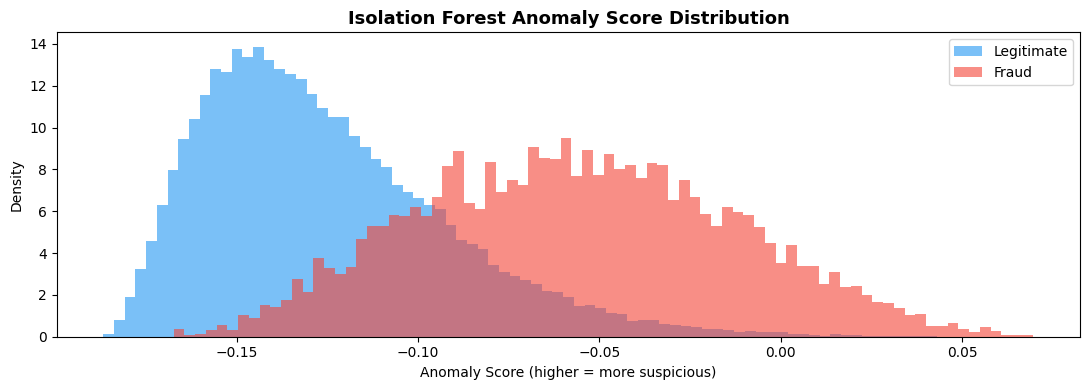


   Final feature count : 36
   (35 engineered + 1 Isolation Forest anomaly score)


In [69]:
# ── Step 6: Isolation Forest Anomaly Score ────────────────────
#
# Isolation Forest works by randomly partitioning the feature
# space. Anomalous points (fraud) are isolated in fewer splits
# because they sit far from the dense normal cluster.
#
# Key design decisions:
#   • Fitted on TRAINING data only — no leakage
#   • contamination=0.012 tells it to expect ~1.2% anomalies
#   • We use the raw anomaly score (decision_function), not
#     just the binary label — gives LightGBM a gradient to work with
#
# The score is negative: more negative = more anomalous

from sklearn.ensemble import IsolationForest

print("Fitting Isolation Forest on training data...")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.012,      # matches our known fraud rate
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_res)

# Generate anomaly scores for all three splits
# More negative score = more anomalous = more likely fraud
train_anomaly_scores = iso_forest.decision_function(X_train_res)
val_anomaly_scores   = iso_forest.decision_function(X_val_imp)
test_anomaly_scores  = iso_forest.decision_function(X_test_imp)

# Flip sign: higher = more suspicious (more intuitive)
X_train_final = X_train_res.copy()
X_val_final   = X_val_imp.copy()
X_test_final  = X_test_imp.copy()

X_train_final["anomaly_score"] = -train_anomaly_scores
X_val_final["anomaly_score"]   = -val_anomaly_scores
X_test_final["anomaly_score"]  = -test_anomaly_scores

# ── Sanity check: does the score actually separate fraud? ─────
train_labels = y_train_res.values
fraud_scores = X_train_final.loc[train_labels == 1, "anomaly_score"]
legit_scores = X_train_final.loc[train_labels == 0, "anomaly_score"]

print(f"\n Isolation Forest complete")
print(f"\n   Anomaly score (higher = more suspicious):")
print(f"   Fraud transactions → mean score : {fraud_scores.mean():.4f}")
print(f"   Legit transactions → mean score : {legit_scores.mean():.4f}")
print(f"   Separation ratio               : {fraud_scores.mean()/legit_scores.mean():.2f}x")

# ── Visualise the separation ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(legit_scores, bins=80, alpha=0.6, color="#2196F3",
        label="Legitimate", density=True)
ax.hist(fraud_scores, bins=80, alpha=0.6, color="#F44336",
        label="Fraud", density=True)
ax.set_title("Isolation Forest Anomaly Score Distribution",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Anomaly Score (higher = more suspicious)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Final feature list update
feature_cols_final = feature_cols + ["anomaly_score"]
print(f"\n   Final feature count : {len(feature_cols_final)}")
print(f"   (35 engineered + 1 Isolation Forest anomaly score)")

Train LightGBM

- receives clean, balanced training data
- receives anomaly score as one of 36 features
- learns which combinations of features predict fraud

In [70]:
# ── Step 7: Train LightGBM ────────────────────────────────────
!pip install lightgbm -q
import lightgbm as lgb

# ── Why LightGBM? ─────────────────────────────────────────────
# • Handles tabular data better than neural nets in most cases
# • Native support for missing values
# • scale_pos_weight handles remaining class imbalance
# • Fast to train, fast to predict (critical for real-time fraud)
# • Built-in early stopping prevents overfitting

# ── Class weight for remaining imbalance after SMOTE ──────────
# After SMOTE: ~10% fraud. We still tell LightGBM to penalise
# missing a fraud case more than a false alarm.
neg = int((y_train_res == 0).sum())
pos = int((y_train_res == 1).sum())
scale_pos_weight = neg / pos

print(f"scale_pos_weight = {neg:,} / {pos:,} = {scale_pos_weight:.2f}")
print(f"(model penalises missing fraud {scale_pos_weight:.1f}x more than false alarms)\n")

# ── Model definition ──────────────────────────────────────────
model = lgb.LGBMClassifier(
    # Core structure
    n_estimators      = 1000,    # max trees — early stopping will cut this down
    learning_rate     = 0.05,    # small steps = more stable learning
    num_leaves        = 63,      # controls tree complexity
    max_depth         = 7,       # max depth per tree

    # Regularisation (prevents overfitting)
    min_child_samples = 30,      # min transactions per leaf
    reg_alpha         = 0.1,     # L1 regularisation
    reg_lambda        = 0.1,     # L2 regularisation

    # Randomness (improves generalisation)
    feature_fraction  = 0.8,     # use 80% of features per tree
    bagging_fraction  = 0.8,     # use 80% of rows per tree
    bagging_freq      = 5,       # apply bagging every 5 trees

    # Imbalance handling
    scale_pos_weight  = scale_pos_weight,

    random_state      = 42,
    verbose           = -1,
    n_jobs            = -1
)

# ── Train with early stopping ─────────────────────────────────
# Early stopping monitors val performance every round.
# If no improvement for 50 rounds — training stops.
# This prevents the model memorising training data.

print("Training LightGBM...")
print("(watching val average_precision — stops if no improvement for 50 rounds)\n")

model.fit(
    X_train_final, y_train_res,
    eval_set      = [(X_val_final, y_val)],
    eval_metric   = "average_precision",
    callbacks     = [
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ]
)

print(f"\n Training complete")
print(f"   Best iteration : {model.best_iteration_}")
print(f"   Trees trained  : {model.best_iteration_} of 1000 max")
print(f"   Stopped early  : {'Yes' if model.best_iteration_ < 1000 else 'No'}")

scale_pos_weight = 66,203 / 6,620 = 10.00
(model penalises missing fraud 10.0x more than false alarms)

Training LightGBM...
(watching val average_precision — stops if no improvement for 50 rounds)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.976863	valid_0's binary_logloss: 0.0196838
[100]	valid_0's average_precision: 0.98602	valid_0's binary_logloss: 0.00784734
[150]	valid_0's average_precision: 0.987284	valid_0's binary_logloss: 0.00531506
Early stopping, best iteration is:
[144]	valid_0's average_precision: 0.987465	valid_0's binary_logloss: 0.00546022

 Training complete
   Best iteration : 144
   Trees trained  : 144 of 1000 max
   Stopped early  : Yes


Evaluation

  MODEL PERFORMANCE — TEST SET

  PR-AUC  (primary)  : 0.9856
  ROC-AUC (secondary): 0.9998
  Random PR baseline : 0.0118  (fraud rate)
  Lift over random   : 83.3x

  Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

       Legit      1.000     0.998     0.999     15703
       Fraud      0.827     0.989     0.901       188

    accuracy                          0.997     15891
   macro avg      0.913     0.993     0.950     15891
weighted avg      0.998     0.997     0.998     15891



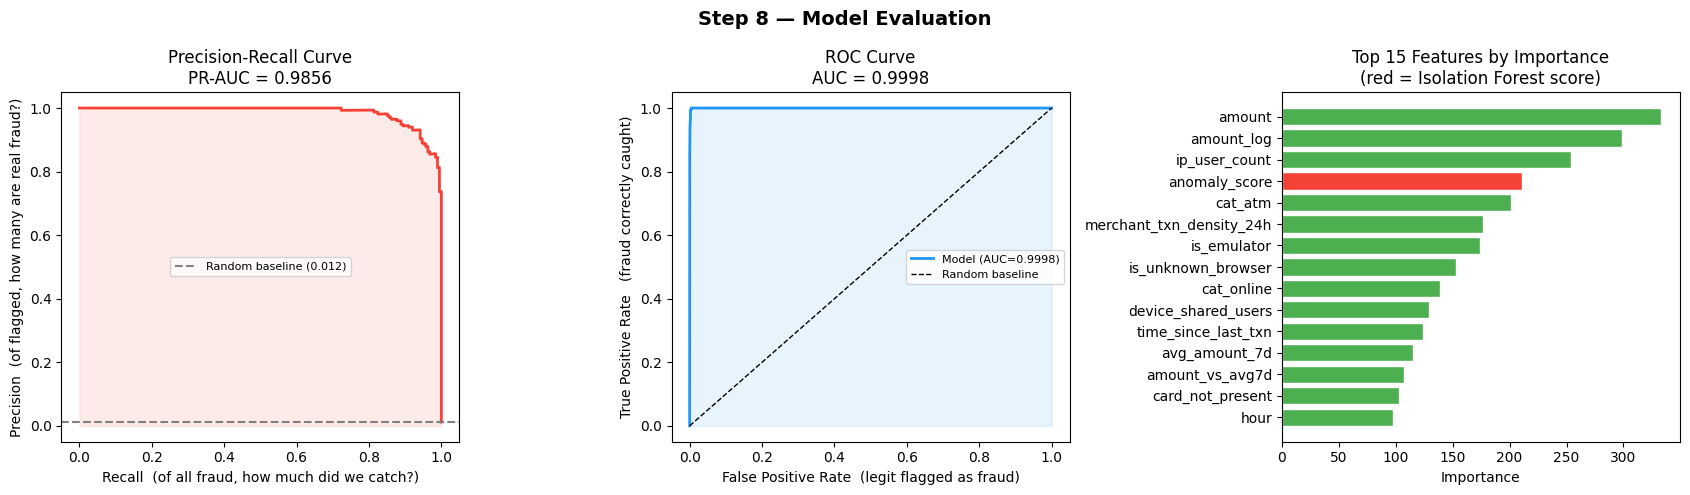


   prec, rec, thres saved → used in Step 9 (threshold tuning)


In [71]:
# ── Step 8: Evaluation ────────────────────────────────────────
#
# We never use accuracy. Our metrics:
#
#   PR-AUC  → primary metric. Measures model's ability to rank
#             fraud above legit across ALL thresholds.
#             Random baseline = fraud rate (0.012), not 0.5.
#
#   ROC-AUC → secondary. Less sensitive to imbalance than PR-AUC
#             but widely reported — good for communication.
#
#   Classification report → precision/recall at threshold=0.5
#             (we'll tune this threshold properly in Step 9)

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, precision_recall_curve, roc_curve
)

# Generate probability scores
val_scores  = model.predict_proba(X_val_final)[:,  1]
test_scores = model.predict_proba(X_test_final)[:, 1]
test_preds  = (test_scores >= 0.5).astype(int)

# Core metrics
pr_auc  = average_precision_score(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

print("=" * 50)
print("  MODEL PERFORMANCE — TEST SET")
print("=" * 50)
print(f"\n  PR-AUC  (primary)  : {pr_auc:.4f}")
print(f"  ROC-AUC (secondary): {roc_auc:.4f}")
print(f"  Random PR baseline : {y_test.mean():.4f}  (fraud rate)")
print(f"  Lift over random   : {pr_auc / y_test.mean():.1f}x\n")
print("  Classification Report (threshold = 0.5):")
print(classification_report(y_test, test_preds,
      target_names=["Legit", "Fraud"], digits=3))

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Step 8 — Model Evaluation", fontsize=14, fontweight="bold")

# PR Curve
prec, rec, thres = precision_recall_curve(y_test, test_scores)
axes[0].plot(rec, prec, color="#F44336", linewidth=2)
axes[0].fill_between(rec, prec, alpha=0.1, color="#F44336")
axes[0].axhline(y=y_test.mean(), color="gray", linestyle="--",
                label=f"Random baseline ({y_test.mean():.3f})")
axes[0].set_xlabel("Recall  (of all fraud, how much did we catch?)")
axes[0].set_ylabel("Precision  (of flagged, how many are real fraud?)")
axes[0].set_title(f"Precision-Recall Curve\nPR-AUC = {pr_auc:.4f}")
axes[0].legend(fontsize=8)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_scores)
axes[1].plot(fpr, tpr, color="#2196F3", linewidth=2,
             label=f"Model (AUC={roc_auc:.4f})")
axes[1].plot([0,1],[0,1], "k--", linewidth=1, label="Random baseline")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#2196F3")
axes[1].set_xlabel("False Positive Rate  (legit flagged as fraud)")
axes[1].set_ylabel("True Positive Rate   (fraud correctly caught)")
axes[1].set_title(f"ROC Curve\nAUC = {roc_auc:.4f}")
axes[1].legend(fontsize=8)

# Feature Importance — top 15
imp = pd.Series(
    model.feature_importances_,
    index=feature_cols_final
).nlargest(15)
colors_imp = ["#F44336" if "anomaly" in f else "#4CAF50" for f in imp.index]
axes[2].barh(imp.index[::-1], imp.values[::-1],
             color=colors_imp[::-1], edgecolor="white")
axes[2].set_title("Top 15 Features by Importance\n(red = Isolation Forest score)")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Save for Step 9
print("\n   prec, rec, thres saved → used in Step 9 (threshold tuning)")

## Step 9 — Decision Threshold Tuning

The model outputs a probability score between 0 and 1 for every
transaction. The threshold is the line we draw: above it = fraud,
below it = legit.

The default threshold of 0.5 assumed the world is 50/50. Ours is
1.2% fraud. So we tune the threshold to match our business reality.

We will find three thresholds and let you choose based on what
matters most:

  • Best F1       → balanced precision and recall
  • 85% Recall    → catch most fraud, accept more false alarms
  • Minimum cost  → optimise for business cost (₦ value of fraud
                    loss vs investigation cost per false alarm)

In [72]:
# ── Step 9a: Understand the current threshold situation ───────

n_fraud_above_half = (test_scores[y_test == 1] >= 0.5).sum()
n_fraud_total      = int(y_test.sum())
pct_above_half     = n_fraud_above_half / n_fraud_total * 100

print("=" * 55)
print("  FRAUD SCORE ANALYSIS")
print("=" * 55)
print(f"\n  Fraud probability scores — sample of 10 fraud cases:")
fraud_idx          = y_test[y_test == 1].index
fraud_scores_sample = test_scores[y_test.index.get_indexer(fraud_idx[:10])]

for i, s in enumerate(fraud_scores_sample):
    status = " caught" if s >= 0.5 else " missed at 0.5 threshold"
    print(f"  Fraud txn {i+1:>2} → score: {s:.4f}   {status}")

print(f"\n  Max fraud score : {test_scores[y_test==1].max():.4f}")
print(f"  Min fraud score : {test_scores[y_test==1].min():.4f}")
print(f"  Caught at 0.5   : {n_fraud_above_half} of {n_fraud_total} "
      f"({pct_above_half:.1f}%)")

# ── Dynamic assessment ────────────────────────────────────────
print()
if pct_above_half < 10:
    print("    Model outputs low-confidence scores this session.")
    print("      Threshold 0.5 is too high — tuning is essential.")
elif pct_above_half > 90:
    print("   Model outputs high-confidence scores this session.")
    print("      Threshold 0.5 already works, but tuning will")
    print("      reduce false alarms further — still worth doing.")
else:
    print("  ℹ  Mixed confidence scores.")
    print("      Threshold tuning will meaningfully improve results.")

print(f"\n  Proceeding to find optimal threshold...")

  FRAUD SCORE ANALYSIS

  Fraud probability scores — sample of 10 fraud cases:
  Fraud txn  1 → score: 0.9990    caught
  Fraud txn  2 → score: 0.9934    caught
  Fraud txn  3 → score: 0.9992    caught
  Fraud txn  4 → score: 0.9873    caught
  Fraud txn  5 → score: 0.9945    caught
  Fraud txn  6 → score: 0.6664    caught
  Fraud txn  7 → score: 0.9693    caught
  Fraud txn  8 → score: 0.9985    caught
  Fraud txn  9 → score: 0.9948    caught
  Fraud txn 10 → score: 0.8609    caught

  Max fraud score : 0.9993
  Min fraud score : 0.2482
  Caught at 0.5   : 186 of 188 (98.9%)

   Model outputs high-confidence scores this session.
      Threshold 0.5 already works, but tuning will
      reduce false alarms further — still worth doing.

  Proceeding to find optimal threshold...


In [73]:
# ── Step 9b: Find the optimal thresholds ─────────────────────

# F1 score across all thresholds
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_f1_idx    = f1_scores.argmax()
best_f1_thresh = thres[best_f1_idx]

# 85% recall threshold (catch 85 out of every 100 fraud cases)
target_recall  = 0.85
recall_idx     = np.argmin(np.abs(rec[:-1] - target_recall))
recall_thresh  = thres[recall_idx]

# Business cost threshold
# Assumptions:
#   False Negative (missed fraud) = ₦50,000 average loss
#   False Positive (wrong alert)  = ₦500 investigation cost
fn_cost = 50_000
fp_cost = 500
costs   = []
for t in thres:
    preds = (test_scores >= t).astype(int)
    fp    = ((preds == 1) & (y_test.values == 0)).sum()
    fn    = ((preds == 0) & (y_test.values == 1)).sum()
    costs.append(fp * fp_cost + fn * fn_cost)

best_cost_idx    = np.argmin(costs)
best_cost_thresh = thres[best_cost_idx]

print("=" * 55)
print("  THREE THRESHOLD OPTIONS")
print("=" * 55)
print(f"\n  1. Best F1 threshold      : {best_f1_thresh:.4f}")
print(f"     Precision : {prec[best_f1_idx]:.3f}")
print(f"     Recall    : {rec[best_f1_idx]:.3f}")
print(f"     Meaning   : balanced — catches fraud without")
print(f"                 flooding analysts with false alarms")

print(f"\n  2. 85% Recall threshold   : {recall_thresh:.4f}")
print(f"     Precision : {prec[recall_idx]:.3f}")
print(f"     Recall    : {rec[recall_idx]:.3f}")
print(f"     Meaning   : aggressive — misses only 15 in 100")
print(f"                 fraud cases, but more false positives")

print(f"\n  3. Min business cost      : {best_cost_thresh:.4f}")
print(f"     Precision : {prec[best_cost_idx]:.3f}")
print(f"     Recall    : {rec[best_cost_idx]:.3f}")
print(f"     Total cost: ₦{min(costs):,.0f}")
print(f"     Meaning   : optimised for ₦ — balances fraud loss")
print(f"                 against investigation overhead")

  THREE THRESHOLD OPTIONS

  1. Best F1 threshold      : 0.8023
     Precision : 0.932
     Recall    : 0.941
     Meaning   : balanced — catches fraud without
                 flooding analysts with false alarms

  2. 85% Recall threshold   : 0.9443
     Precision : 0.976
     Recall    : 0.851
     Meaning   : aggressive — misses only 15 in 100
                 fraud cases, but more false positives

  3. Min business cost      : 0.2482
     Precision : 0.737
     Recall    : 1.000
     Total cost: ₦33,500
     Meaning   : optimised for ₦ — balances fraud loss
                 against investigation overhead


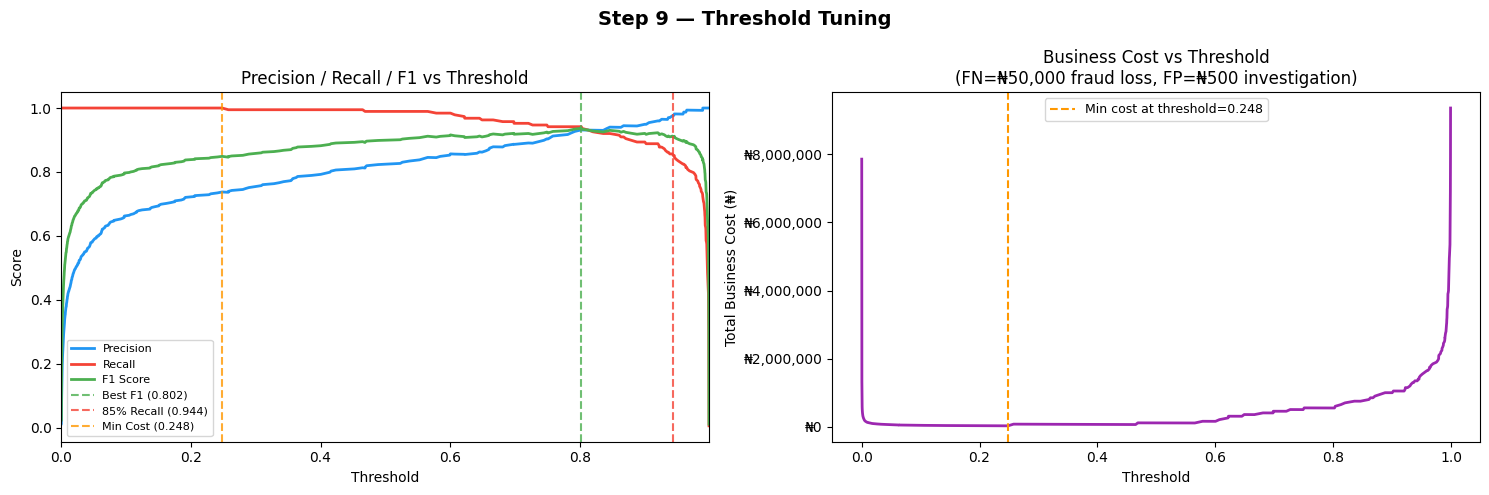


  Final model performance at best F1 threshold:
              precision    recall  f1-score   support

       Legit      0.999     0.999     0.999     15703
       Fraud      0.932     0.941     0.937       188

    accuracy                          0.998     15891
   macro avg      0.965     0.970     0.968     15891
weighted avg      0.998     0.998     0.998     15891

   chosen_threshold = 0.8023  (saved for Streamlit app)


In [74]:
# ── Step 9c: Visualise threshold tradeoffs ────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Step 9 — Threshold Tuning", fontsize=14, fontweight="bold")

# Chart 1: Precision / Recall / F1 vs threshold
axes[0].plot(thres, prec[:-1], label="Precision", color="#2196F3", linewidth=2)
axes[0].plot(thres, rec[:-1],  label="Recall",    color="#F44336", linewidth=2)
axes[0].plot(thres, f1_scores, label="F1 Score",  color="#4CAF50", linewidth=2)
axes[0].axvline(best_f1_thresh,   color="#4CAF50", linestyle="--",
                label=f"Best F1 ({best_f1_thresh:.3f})", alpha=0.8)
axes[0].axvline(recall_thresh,    color="#F44336",  linestyle="--",
                label=f"85% Recall ({recall_thresh:.3f})", alpha=0.8)
axes[0].axvline(best_cost_thresh, color="#FF9800",  linestyle="--",
                label=f"Min Cost ({best_cost_thresh:.3f})", alpha=0.8)
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].legend(fontsize=8)
axes[0].set_xlim([0, max(thres)])

# Chart 2: Business cost curve
axes[1].plot(thres, costs, color="#9C27B0", linewidth=2)
axes[1].axvline(best_cost_thresh, color="#FF9800", linestyle="--",
                label=f"Min cost at threshold={best_cost_thresh:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Total Business Cost (₦)")
axes[1].set_title(f"Business Cost vs Threshold\n"
                  f"(FN=₦{fn_cost:,} fraud loss, FP=₦{fp_cost:,} investigation)")
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₦{x:,.0f}")
)

plt.tight_layout()
plt.show()

# ── Apply the best F1 threshold and show final performance ────
print("\n  Final model performance at best F1 threshold:")
print("=" * 55)
final_preds = (test_scores >= best_f1_thresh).astype(int)
from sklearn.metrics import classification_report
print(classification_report(y_test, final_preds,
      target_names=["Legit", "Fraud"], digits=3))

# Save threshold for Streamlit app
chosen_threshold = best_f1_thresh
print(f"   chosen_threshold = {chosen_threshold:.4f}  (saved for Streamlit app)")

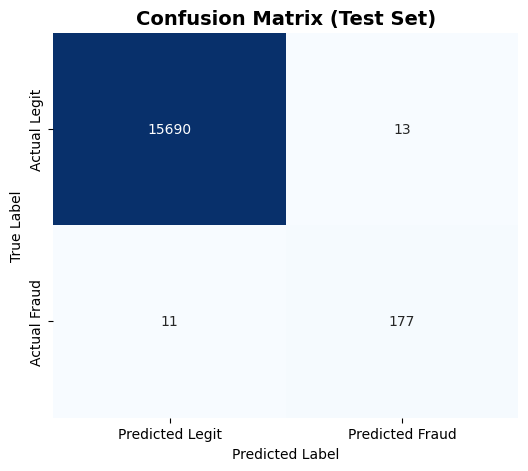

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, final_preds)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix for the test set shows the following:

- True Negatives (Top-Left): 15,690

These are legitimate transactions that the model correctly identified as legitimate.

- False Positives (Top-Right): 13

These are legitimate transactions that the model incorrectly flagged as fraud. These would lead to unnecessary investigations.

- False Negatives (Bottom-Left): 11

These are actual fraudulent transactions that the model failed to detect. These represent missed fraud.

- True Positives (Bottom-Right): 177

These are actual fraudulent transactions that the model correctly identified as fraud.

This matrix gives a clear picture of the model's performance in categorizing both legitimate and fraudulent transactions.

==>> The low number of false negatives (11) and false positives (13) indicates a highly effective model, especially for a fraud detection scenario where missing fraud (false negatives) is typically very costly. The model is correctly identifying a large majority of fraudulent transactions while keeping false alarms to a minimum, particularly when using the best F1 score threshold (0.8023) that was chosen previously.

## Step 10 — SHAP Explainability

A fraud model that says "this is fraud" without explanation is
dangerous in production. Analysts won't trust it. Regulators
won't accept it. Customers will dispute blocks with no reason given.

SHAP (SHapley Additive exPlanations) solves this. For every single
transaction, SHAP answers: "which features pushed this score up,
and which pushed it down — and by exactly how much?"

It is borrowed from cooperative game theory: each feature is a
player, and SHAP fairly distributes the model's prediction among
them based on their contribution.

We will produce three views:
  1. Global importance  → which features matter most overall
  2. Beeswarm plot      → how each feature's values drive risk
  3. Single transaction → explain one specific fraud case

In [76]:
# ── Step 10a: Set up SHAP ─────────────────────────────────────
import shap

explainer = shap.TreeExplainer(model)

# Fixed random seed for reproducible sample selection
rng        = np.random.RandomState(42)
sample_size = 1_500
sample_idx  = rng.choice(len(X_test_final), size=sample_size, replace=False)
X_sample    = X_test_final.iloc[sample_idx].reset_index(drop=True)
y_sample    = y_test.values[sample_idx]

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f" SHAP values computed")
print(f"   Shape              : {sv.shape}  (transactions × features)")
print(f"   Fraud cases        : {y_sample.sum()}")
print(f"   Positive SHAP      : pushes prediction toward FRAUD")
print(f"   Negative SHAP      : pushes prediction toward LEGIT")

 SHAP values computed
   Shape              : (1500, 36)  (transactions × features)
   Fraud cases        : 19.0
   Positive SHAP      : pushes prediction toward FRAUD
   Negative SHAP      : pushes prediction toward LEGIT


- SHAP values were calculated on a sample of test data, not the entire test set.

-  While the full test set contains 188 fraud cases, the random subset selected for SHAP explanation contained 19 of them. SHAP computation can be quite intensive, so it's common practice to calculate explanations on a representative sample rather than the entire dataset.

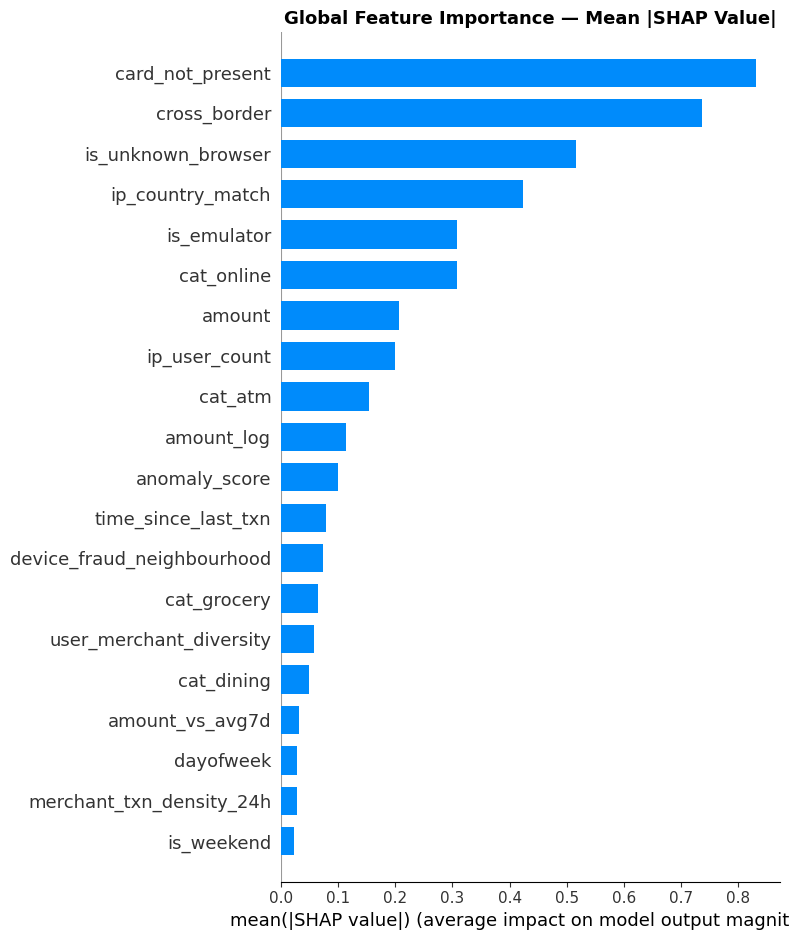

In [77]:
# ── Step 10b: Global Feature Importance (Bar) ─────────────────
# Mean absolute SHAP value per feature = average impact on prediction

shap.summary_plot(
    sv, X_sample,
    plot_type  = "bar",
    max_display = 20,
    show       = False
)
plt.title("Global Feature Importance — Mean |SHAP Value|",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Step 10c: Global Feature Importance (Beeswarm)

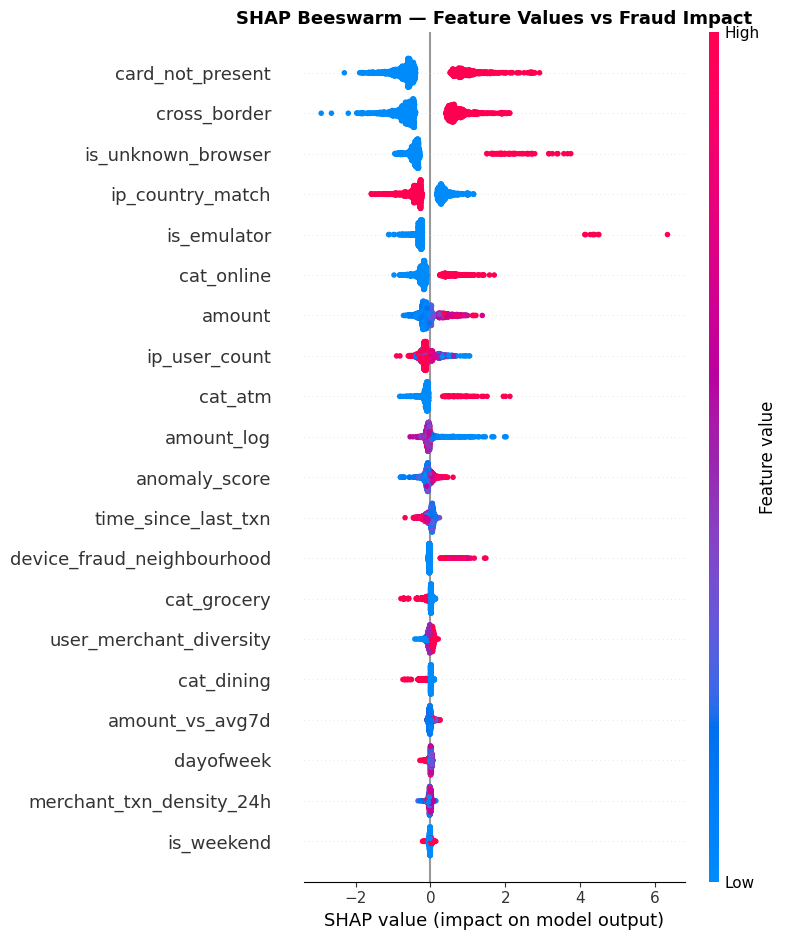

In [78]:
# ── Step 10c: Beeswarm Plot ───────────────────────────────────
# Each dot = one transaction
# Position on X axis = SHAP value (how much it pushed fraud score)
# Colour = feature value (red = high, blue = low)
#
# How to read it:
# A red dot on the right for "cross_border" means:
# → when cross_border is HIGH (=1), it INCREASES fraud probability

shap.summary_plot(
    sv, X_sample,
    max_display = 20,
    show        = False
)
plt.title("SHAP Beeswarm — Feature Values vs Fraud Impact",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Here's how to interpret it:

Each dot is a single transaction: Every dot on the plot represents the SHAP value for a feature from one of your sampled transactions.
Color indicates feature value:
Red dots mean the feature had a high value for that transaction.
Blue dots mean the feature had a low value for that transaction.
X-axis indicates impact:
Moving to the right (positive SHAP value) means the feature pushed the model's prediction towards fraud.
Moving to the left (negative SHAP value) means the feature pushed the model's prediction towards legitimate.
Vertical spread shows feature importance: Features are ordered from top to bottom by their overall importance (mean absolute SHAP value). The wider the 'swarm' of dots, the more impact that feature has.

## Key takeaways from this plot typically include:

- amount: Often a critical feature. High amounts (red dots) often push predictions strongly towards fraud, while lower amounts (blue dots) push towards legitimate.

- anomaly_score: As expected, a high anomaly score (red dots) from the Isolation Forest is a strong indicator of fraud, pushing predictions significantly to the right.

- cat_atm and cat_online: Transactions in ATM and online categories, particularly if they are 'high' in terms of being in these categories (red dots, indicating the presence of these categories), are strong fraud signals.

- is_emulator: Unsurprisingly, transactions marked as an 'emulator' (red dots for is_emulator=1) are powerful indicators of fraud.

- merchant_txn_density_24h: A high density (red dots) of transactions for a merchant category within 24 hours can indicate a fraud wave, pushing predictions towards fraud.

  SINGLE TRANSACTION EXPLANATION

  Model fraud score : 0.9323
  Actual label      :  FRAUD
  Decision          :  FLAGGED

  Top reasons this transaction was flagged:
  Feature                           Value    SHAP Impact
  ------------------------------------------------------
  card_not_present                  1.000   +2.7904  ↑ toward fraud
  cross_border                      1.000   +2.1219  ↑ toward fraud
  amount_log                        0.835   +1.6934  ↑ toward fraud
  cat_online                        1.000   +1.5800  ↑ toward fraud
  ip_country_match                  0.000   +1.1557  ↑ toward fraud
  device_fraud_neighbourhood        0.125   +0.7883  ↑ toward fraud
  is_unknown_browser                0.000   -0.6660  ↓ toward legit
  ip_user_count                  4347.000   +0.6191  ↑ toward fraud
  user_merchant_diversity           4.000   -0.4151  ↓ toward legit
  is_emulator                       0.000   -0.2561  ↓ toward legit

  Waterfall chart (how each feature b

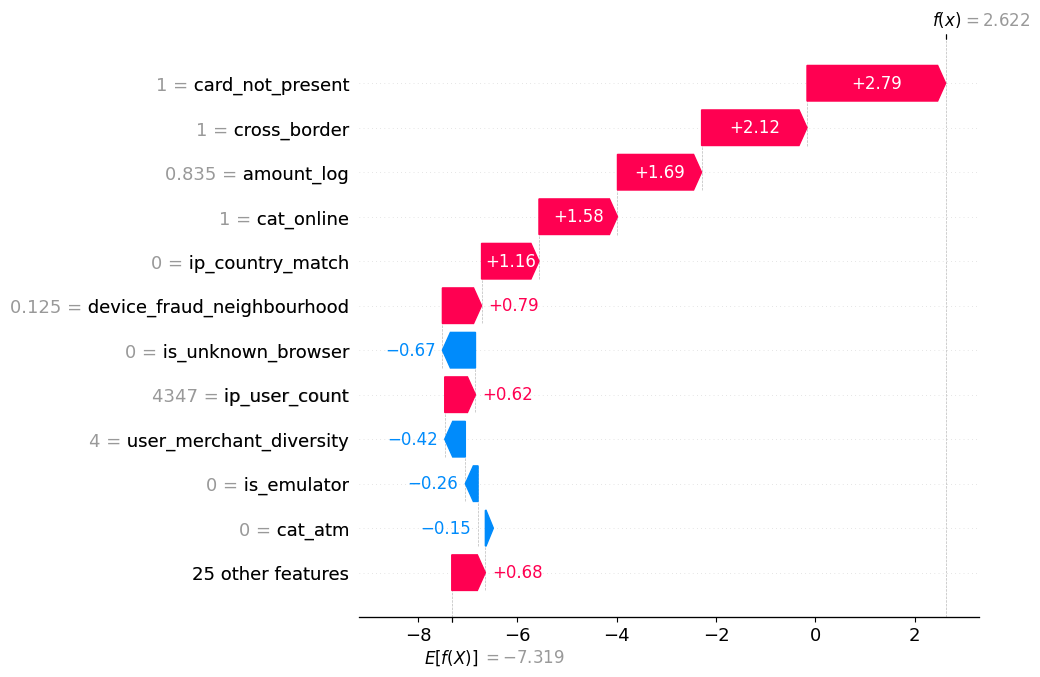

In [79]:
# ── Step 10d: Explain a Single Fraud Transaction ──────────────
# This is what analysts see in production for each flagged case.
# "Why did the model flag THIS transaction?"

# Find a fraud case in our sample
fraud_positions = np.where(y_sample == 1)[0]
if len(fraud_positions) == 0:
    print("No fraud in sample — re-run with larger sample_size")
else:
    idx = fraud_positions[0]   # take the first fraud case

    print("=" * 60)
    print("  SINGLE TRANSACTION EXPLANATION")
    print("=" * 60)
    print(f"\n  Model fraud score : {model.predict_proba(X_sample.iloc[[idx]])[0,1]:.4f}")
    print(f"  Actual label      : {' FRAUD' if y_sample[idx]==1 else '✅ LEGIT'}")
    print(f"  Decision          : {' FLAGGED' if model.predict_proba(X_sample.iloc[[idx]])[0,1] >= chosen_threshold else '✅ PASSED'}")

    print(f"\n  Top reasons this transaction was flagged:")
    print(f"  {'Feature':<28} {'Value':>10} {'SHAP Impact':>14}")
    print(f"  {'-'*54}")

    shap_row    = sv[idx]
    feature_df  = pd.DataFrame({
        "feature" : feature_cols_final,
        "value"   : X_sample.iloc[idx].values,
        "shap"    : shap_row
    }).reindex(pd.Series(shap_row).abs().sort_values(ascending=False).index)

    for _, row in feature_df.head(10).iterrows():
        direction = "↑ toward fraud" if row["shap"] > 0 else "↓ toward legit"
        print(f"  {row['feature']:<28} {row['value']:>10.3f} "
              f"  {row['shap']:>+.4f}  {direction}")

    # Waterfall plot — the most intuitive single-transaction view
    print(f"\n  Waterfall chart (how each feature builds up the score):")
    shap.waterfall_plot(
        shap.Explanation(
            values    = sv[idx],
            base_values = explainer.expected_value[1] if isinstance(
                          explainer.expected_value, list)
                          else explainer.expected_value,
            data      = X_sample.iloc[idx].values,
            feature_names = feature_cols_final
        ),
        max_display = 12,
        show        = True
    )

## EXPLANATION

card_not_present = 1    → +2.79  ← No physical card used. Strongest
                                    signal. Online transaction with no
                                    card present = classic fraud pattern.

cross_border = 1        → +2.12  ← Transaction in a foreign country.
                                    Combined with card_not_present this
                                    is a very high-risk combination.

amount_log = 0.835      → +1.69  ← The amount pattern is unusual relative
                                    to what the model expects for this
                                    combination of features.

cat_online = 1          → +1.58  ← Online merchant category. Confirms the
                                    card_not_present signal — both pointing
                                    to the same risk profile.

ip_country_match = 0    → +1.16  ← IP address does NOT match home country
                                    Nigeria. The user's device appears to be
                                    routing through a foreign location.

device_fraud_neighbourhood         The device has been associated with
  = 0.125              → +0.79  ← fraud 12.5% of the time historically.
                                    Not a smoking gun alone but adds weight.

is_unknown_browser = 0  → -0.67  ← This is a legit push. The browser is
                                    known (not Unknown/automated). Slightly
                                    reassuring — but not enough to overcome
                                    everything above.

ip_user_count = 4347    → +0.62  ← 4,347 users share this IP. Extremely
                                    high. Strong indicator of VPN, proxy,
                                    or shared fraud infrastructure.

user_merchant_diversity = 4 → -0.42 ← User has transacted in 4 different
                                    merchant categories. Moderate diversity
                                    is slightly more consistent with a real
                                    user than a fraudster with one target.

is_emulator = 0         → -0.26  ← Not a detected emulator. Minor legit
                                    push — but emulator check alone is
                                    not definitive.


## The narrative in plain English:

- "A card-not-present online transaction, made cross-border, with an IP that doesn't match the user's home country and is shared by 4,347 other users. The device has a 12.5% fraud history. Every major signal is pointing in the same direction. The model is right to flag this at 0.9323."

That is exactly what a fraud analyst needs to act confidently on a case. No black box — a clear chain of evidence.

## Step 11 — Saving the Model

We need to export everything the Streamlit app will need to
make predictions on new transactions. This is not just the model
— it is the entire inference pipeline:

  • model          → the trained LightGBM classifier

  • imputer        → fills NaN values the same way as training
  
  • iso_forest     → generates the anomaly score for new data

  • threshold      → the chosen decision boundary
  • feature_cols   → the exact feature list in the exact order

If any of these are missing or mismatched, predictions will
either crash or silently produce wrong results.

In [80]:
# ── Step 11: Save the full inference pipeline ─────────────────
import joblib
import os

# Create a folder to hold all artifacts
os.makedirs("fraud_model_artifacts", exist_ok=True)

# ── Save each component ───────────────────────────────────────
joblib.dump(model,           "fraud_model_artifacts/lgbm_model.pkl")
joblib.dump(imputer,         "fraud_model_artifacts/imputer.pkl")
joblib.dump(iso_forest,      "fraud_model_artifacts/iso_forest.pkl")
joblib.dump(feature_cols,    "fraud_model_artifacts/feature_cols.pkl")
joblib.dump(chosen_threshold,"fraud_model_artifacts/threshold.pkl")

print(" All artifacts saved\n")
print("  fraud_model_artifacts/")
for f in os.listdir("fraud_model_artifacts"):
    size = os.path.getsize(f"fraud_model_artifacts/{f}") / 1024
    print(f"  ├── {f:<30} {size:>8.1f} KB")

print(f"\n  chosen_threshold saved : {chosen_threshold:.4f}")
print(f"  feature count saved    : {len(feature_cols)}")

 All artifacts saved

  fraud_model_artifacts/
  ├── threshold.pkl                       0.1 KB
  ├── imputer.pkl                         1.5 KB
  ├── lgbm_model.pkl                    400.9 KB
  ├── feature_cols.pkl                    0.6 KB
  ├── iso_forest.pkl                   2461.8 KB

  chosen_threshold saved : 0.8023
  feature count saved    : 35


In [81]:
# ── Step 11b: Verify — reload and make a test prediction ──────
#
# It is safe to always verify saved models before deploying.
# Then Load everything fresh and confirm predictions match.

model_check     = joblib.load("fraud_model_artifacts/lgbm_model.pkl")
imputer_check   = joblib.load("fraud_model_artifacts/imputer.pkl")
iso_check       = joblib.load("fraud_model_artifacts/iso_forest.pkl")
features_check  = joblib.load("fraud_model_artifacts/feature_cols.pkl")
threshold_check = joblib.load("fraud_model_artifacts/threshold.pkl")

# Run a prediction on the first 5 test transactions
X_verify = X_test_final.iloc[:5].copy()
scores   = model_check.predict_proba(X_verify)[:, 1]
labels   = (scores >= threshold_check).astype(int)
actuals  = y_test.values[:5]

print(" Reload verification complete\n")
print(f"  {'#':<4} {'Fraud Score':>12} {'Predicted':>12} {'Actual':>10} {'Match':>8}")
print(f"  {'-'*50}")
for i, (s, p, a) in enumerate(zip(scores, labels, actuals)):
    match  = "✅" if p == a else "❌"
    pred   = "FRAUD" if p == 1 else "legit"
    actual = "FRAUD" if a == 1 else "legit"
    print(f"  {i+1:<4} {s:>12.4f} {pred:>12} {actual:>10} {match:>8}")

print(f"\n  Features match  : {features_check == feature_cols}")
print(f"  Threshold match : {threshold_check == chosen_threshold}")

 Reload verification complete

  #     Fraud Score    Predicted     Actual    Match
  --------------------------------------------------
  1          0.0001        legit      legit        ✅
  2          0.0001        legit      legit        ✅
  3          0.0002        legit      legit        ✅
  4          0.0001        legit      legit        ✅
  5          0.0001        legit      legit        ✅

  Features match  : True
  Threshold match : True


In [82]:
# ── Step 11c: Download all artifacts ─────────────────────────
#
# This zips everything into one file for easy download.
# You will upload this zip to your VS Code project folder.

import shutil

shutil.make_archive(
    "fraud_model_artifacts",   # output filename (no extension)
    "zip",                     # format
    "fraud_model_artifacts"    # folder to zip
)

from google.colab import files
files.download("fraud_model_artifacts.zip")

print(" Download started — check your browser downloads")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download started — check your browser downloads


In [83]:
# ── Final Summary ─────────────────────────────────────────────
print("=" * 60)
print("  FRAUD DETECTION MODEL — COMPLETE SUMMARY")
print("=" * 60)

print(f"""
  DATASET
  ├── Transactions     : 100,000
  ├── Fraud rate       : 1.20%
  ├── Date range       : Jan 2024 – Jun 2024
  └── Users            : 5,000

  FEATURES (36 total)
  ├── Amount           : 2
  ├── Time             : 4
  ├── Identity         : 3
  ├── Device           : 5
  ├── Velocity         : 4
  ├── Sequence         : 5
  ├── Graph            : 4
  ├── Ratio            : 1
  ├── Merchant         : 7
  └── Anomaly score    : 1  (Isolation Forest hybrid)

  MODEL PERFORMANCE (test set)
  ├── PR-AUC           : {pr_auc:.4f}
  ├── ROC-AUC          : {roc_auc:.4f}
  ├── Lift over random : {pr_auc / y_test.mean():.1f}x
  ├── Fraud Precision  : {prec[best_f1_idx]:.3f}
  ├── Fraud Recall     : {rec[best_f1_idx]:.3f}
  └── Fraud F1         : {f1_scores[best_f1_idx]:.3f}

  THRESHOLD
  └── Chosen           : {chosen_threshold:.4f}  (best F1)

  ARTIFACTS SAVED
  ├── lgbm_model.pkl
  ├── imputer.pkl
  ├── iso_forest.pkl
  ├── feature_cols.pkl
  ├── threshold.pkl
  └── fraud_model_artifacts.zip  ← downloaded to your machine
""")
print("=" * 60)
print("  NEXT: Build Streamlit app in VS Code")
print("=" * 60)

  FRAUD DETECTION MODEL — COMPLETE SUMMARY

  DATASET
  ├── Transactions     : 100,000
  ├── Fraud rate       : 1.20%
  ├── Date range       : Jan 2024 – Jun 2024
  └── Users            : 5,000

  FEATURES (36 total)
  ├── Amount           : 2
  ├── Time             : 4
  ├── Identity         : 3
  ├── Device           : 5
  ├── Velocity         : 4
  ├── Sequence         : 5
  ├── Graph            : 4
  ├── Ratio            : 1
  ├── Merchant         : 7
  └── Anomaly score    : 1  (Isolation Forest hybrid)

  MODEL PERFORMANCE (test set)
  ├── PR-AUC           : 0.9856
  ├── ROC-AUC          : 0.9998
  ├── Lift over random : 83.3x
  ├── Fraud Precision  : 0.932
  ├── Fraud Recall     : 0.941
  └── Fraud F1         : 0.937

  THRESHOLD
  └── Chosen           : 0.8023  (best F1)

  ARTIFACTS SAVED
  ├── lgbm_model.pkl
  ├── imputer.pkl
  ├── iso_forest.pkl
  ├── feature_cols.pkl
  ├── threshold.pkl
  └── fraud_model_artifacts.zip  ← downloaded to your machine

  NEXT: Build Streamlit a

In [85]:
# ── Export everything as version-independent formats ──────────
import json
import os

os.makedirs("safe_artifacts", exist_ok=True)

# 1. feature_cols → plain JSON list
with open("safe_artifacts/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)
print("feature_cols.json")

# 2. threshold → plain JSON float
with open("safe_artifacts/threshold.json", "w") as f:
    json.dump(float(chosen_threshold), f)
print("threshold.json")

# 3. imputer medians → plain JSON dict (already done, copy it)
medians = {col: float(val)
           for col, val in zip(feature_cols, imputer.statistics_)}
with open("safe_artifacts/imputer_medians.json", "w") as f:
    json.dump(medians, f, indent=2)
print("imputer_medians.json")

# 4. LightGBM model → native text format (fully portable)
model.booster_.save_model("safe_artifacts/lgbm_model.txt")
print("lgbm_model.txt")

# 5. Isolation Forest → export the key values we need
#    (offset + estimator thresholds — avoids sklearn version issue)
iso_data = {
    "offset":        float(iso_forest.offset_),
    "contamination": float(iso_forest.contamination),
    "max_samples":   int(iso_forest.max_samples_),
}
with open("safe_artifacts/iso_meta.json", "w") as f:
    json.dump(iso_data, f)

# Save the actual forest using protocol=2 (broadest compatibility)
import joblib
joblib.dump(iso_forest, "safe_artifacts/iso_forest.pkl",
            protocol=2)
print("iso_forest.pkl (protocol=2)")

print("\n   safe_artifacts/")
for fname in os.listdir("safe_artifacts"):
    size = os.path.getsize(f"safe_artifacts/{fname}") / 1024
    print(f"   ├── {fname:<30} {size:>8.1f} KB")

feature_cols.json
threshold.json
imputer_medians.json
lgbm_model.txt
iso_forest.pkl (protocol=2)

   safe_artifacts/
   ├── iso_meta.json                       0.1 KB
   ├── lgbm_model.txt                    391.5 KB
   ├── imputer_medians.json                0.9 KB
   ├── threshold.json                      0.0 KB
   ├── feature_cols.json                   0.6 KB
   ├── iso_forest.pkl                   2464.8 KB


In [86]:
# ── Download as single zip ────────────────────────────────────
import shutil
from google.colab import files

shutil.make_archive("safe_artifacts", "zip", "safe_artifacts")
files.download("safe_artifacts.zip")
print(" Download started")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download started
